<h1>DSCI 100 Final Project</h1>
<h3>Section 008 Group 19</h3>
<h5>Name: Camille S, Chloe Lin, Erica, Seerat Waraich</h5>

Introduction:
general question and specfic question. Basic explaination of what wrangling we will do, and possible issues.

In [9]:
#cell for loading packages
library(tidyverse)
library(tidymodels)
library(repr)
library(ggplot2)
library(themis)

In [10]:
url <- "https://raw.githubusercontent.com/camillesnyder/Final-Project/refs/heads/main/players.csv"
download.file( url, destfile = "players.csv")
players_data <- read_csv("players.csv")

head(players_data)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


In [11]:
#wrangling data by changing experience to a numerical vector so straightline calculations can be performed
#selecting played_hours vector, experience vector, and people who identify as male as predictors, and subscribe variable as the response
players_wrang <- players_data|>
    select(played_hours, experience, subscribe)|>
    mutate( experience = as_factor(experience))|>
    mutate( experience = fct_recode(experience,
                                    "1" = "Beginner",
                                    "2" = "Amateur",
                                    "3" = "Regular",
                                    "4" = "Veteran",
                                    "5" = "Pro"))|>
    mutate(experience = as.numeric(experience))|>
    mutate(subscribe = as_factor(subscribe))

dim(players_wrang)

[1] 196   3

In [12]:
proportion_of_subscribed <- players_data|>
    summarize(proportion_subscribed = sum(subscribe == "TRUE")/196)

proportion_of_subscribed

proportion_subscribed
<dbl>
0.7346939


In [13]:
player_avgs <- players_wrang|>
    summarize(mean_experience = mean(experience),
              mean_played_hrs = mean(played_hours))

player_avgs

mean_experience,mean_played_hrs
<dbl>,<dbl>
3.153061,5.845918


## 3. Exploratory Data Analysis (EDA)
In this section, we explore the variables that may relate to newsletter subscription, including basic summaries and visualizations. No modeling is performed here.

In [21]:
players_data |>
  count(subscribe)

subscribe,n
<lgl>,<int>
FALSE,52
TRUE,144


This shows the number of players who subscribed versus those who did not. This helps identify whether the classes are balanced or imbalanced.

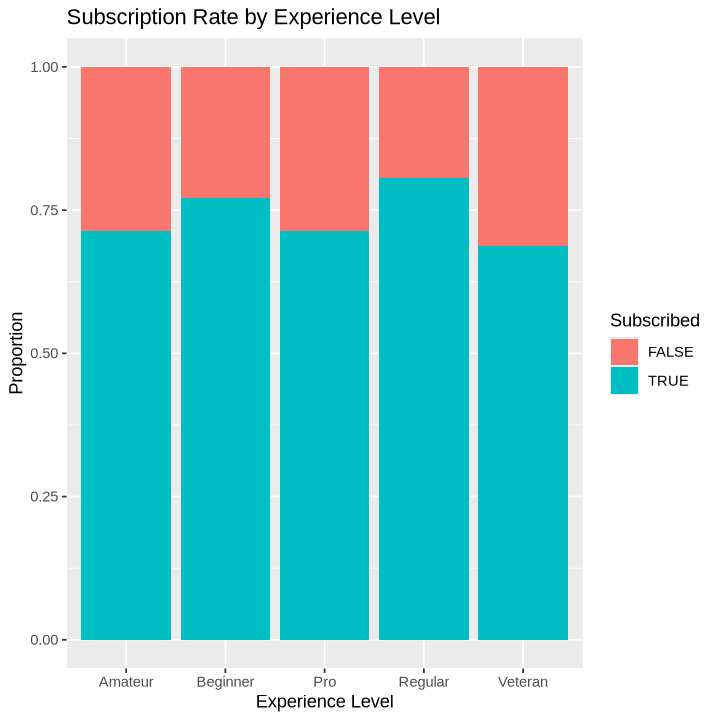

In [22]:
players_data |>
  ggplot(aes(x = experience, fill = subscribe)) +
  geom_bar(position = "fill") +
  labs(title = "Subscription Rate by Experience Level",
       x = "Experience Level",
       y = "Proportion",
       fill = "Subscribed") 

The table shows the number of players who subscribed versus those who did not. There are more subscribers than non-subscribers in this dataset. This means the classes are not perfectly balanced, which is important to keep in mind for modelling because unequal class sizes may influence some methods.

Warning message in geom_histogram(stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


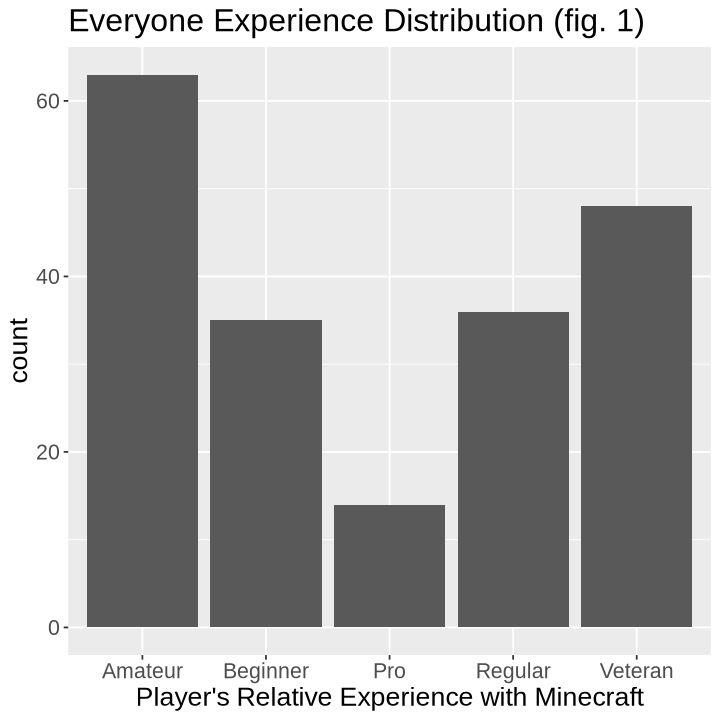

In [15]:
options(repr.plot.height = 6, repr.plot.width = 6)
experience_distribution_before_wrang <- players_data |>
    ggplot( aes(x= experience))+
    geom_histogram(stat = "count")+
    labs(x= "Player's Relative Experience with Minecraft",
        title = "Everyone Experience Distribution (fig. 1)")+
    theme( text = element_text(size = 16))

experience_distribution_before_wrang

Warning message in geom_histogram(stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


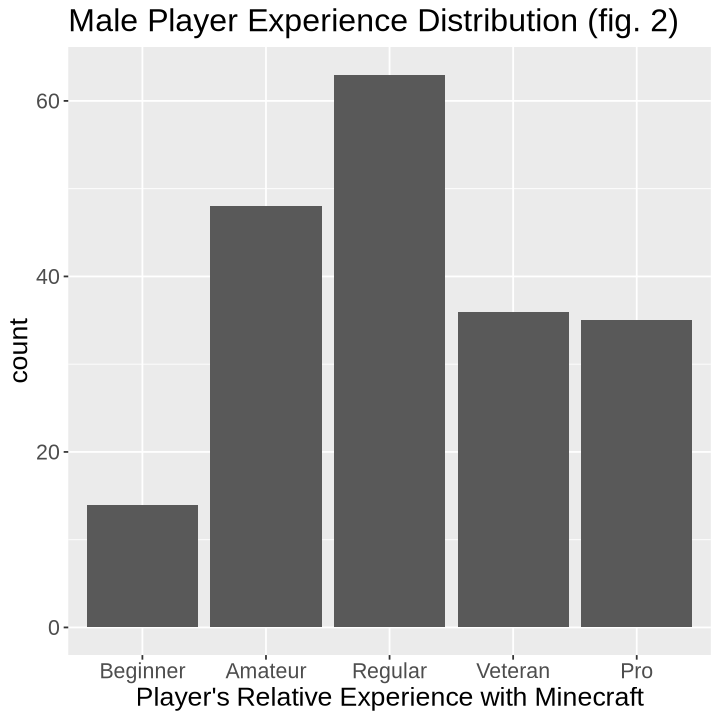

In [16]:
experience_distribution_after_wrang <- players_wrang |>
    mutate( experience = as_factor(experience))|>
    mutate( experience = fct_recode(experience,
                                    "Beginner" = "1",
                                    "Amateur" = "2",
                                    "Regular" = "3",
                                    "Veteran" = "4",
                                    "Pro" = "5"))|>
    ggplot( aes(x= experience))+
    geom_histogram(stat = "count")+
    labs(x= "Player's Relative Experience with Minecraft",
        title = "Male Player Experience Distribution (fig. 2)")+
    theme( text = element_text(size = 16))

experience_distribution_after_wrang 

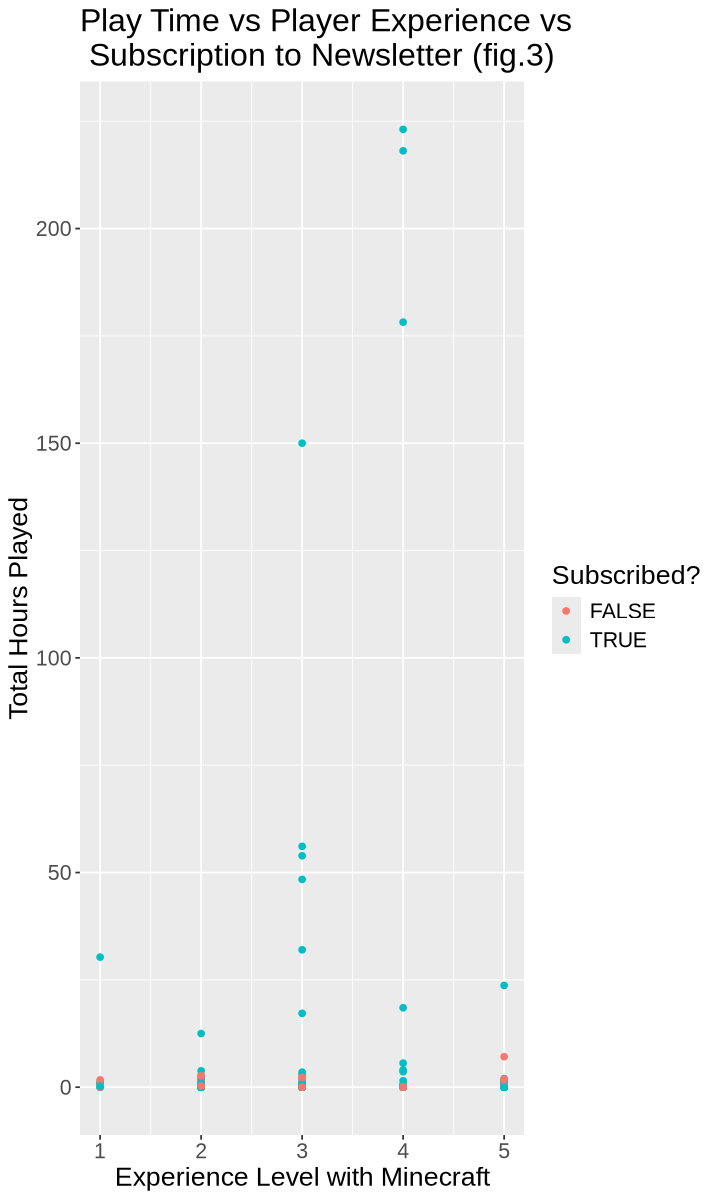

In [17]:
options(repr.plot.height = 10)
#include log scale for hours played
total_hrs_vs_experience_vs_subscribed <- players_wrang|>
    ggplot( aes(y = played_hours, x = experience, color = subscribe))+
    geom_point()+
    labs(y = "Total Hours Played",
         x = "Experience Level with Minecraft",
         title = "Play Time vs Player Experience vs \n Subscription to Newsletter (fig.3)",
        color = "Subscribed?")+
    theme(text = element_text(size = 16))

total_hrs_vs_experience_vs_subscribed

In [18]:
#do knn classification given played hrs obs and experience level obs to predict subscription status
#train on 75% and test on 25%
set.seed(27)

players_split <- players_wrang|>
    initial_split( prop = 0.75, strata = subscribe)

players_train <- training(players_split)

players_test<- testing(players_split)

#model specification
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune())|>
            set_engine("kknn")|>
            set_mode("classification")

k_vals<- tibble(neighbors = seq(from = 1, to = 40, by = 2))
#balance data by stepping up the sample of unsubscribed male players
# ups_recipe <- recipe(subscribe ~ played_hours + experience, data = players_train)|>
#       step_normalize(all_predictors())|>
#     step_upsample(subscribe, over_ratio = 1, skip = FALSE)|>
#     prep()

# players_train <- bake(ups_recipe, players_train)
players_recipe <- recipe(subscribe ~ played_hours + experience, data = players_train)|>
      step_normalize(all_predictors())

players_vfold <- vfold_cv(players_train, v = 10, strata = subscribe)

players_results <- workflow()|>
    add_recipe(players_recipe)|>
    add_model(knn_spec)|>
    tune_grid(resamples = players_vfold, grid = k_vals)|>
    collect_metrics()|>
    filter(.metric == "accuracy")


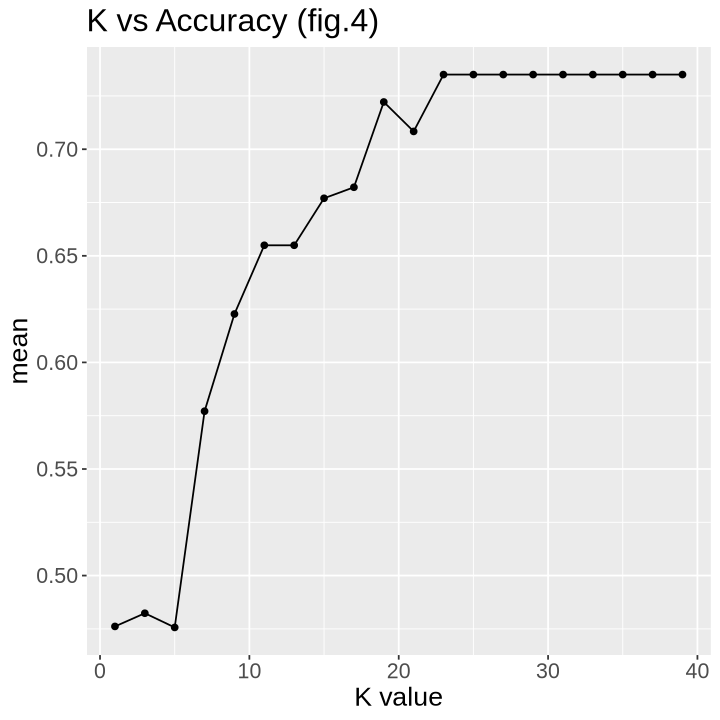

In [19]:
options(repr.plot.height = 6)
K_vs_accuracy <- ggplot(players_results, aes( x= neighbors, y = mean))+
    geom_point()+
    geom_line()+
    labs( x= "K value", title = "K vs Accuracy (fig.4)")+
    theme(text = element_text(size = 16))

K_vs_accuracy

In [20]:
#retrain model based on best parameter value k=19
players_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 19)|>
    set_engine("kknn")|>
    set_mode("classification")

#test new model on test data 
players_fit <- workflow()|>
    add_recipe(players_recipe)|>
    add_model(players_spec)|>
    fit(data = players_train)

test_predictions <- predict(players_fit, players_test)|>
    bind_cols(players_test)|>
    metrics(truth = subscribe, estimate = .pred_class)|>
    filter(.metric == "accuracy")

test_predictions

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.6530612


Basically, the results mean nothing because the accuracy of the predictions is about the same as the proportion of people who are subscribed to the newsletter in the data set with only male players included.